# GVH Diagonal Cubic — RACC-C.4-real.2.10
## GW150914 H1/L1 — Whitening PSD / Window / Regularization Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.10`  
**Noyau GVH Diagonal modifié : NON**

### Question falsifiable

`real.2.9` a conclu, selon la métrique et l'implémentation testées :

\[
\boxed{\texttt{WHITENING-DOMINATED}}
\]

La question devient :

\[
\boxed{\text{Pourquoi le whitening augmente-t-il fortement }f_{\rm nonstable}\ ?}
\]

On part de :

\[
W[X](f)=\frac{X(f)}{\sqrt{\widehat S_n(f)+\epsilon}}
\]

et on audite séparément :

1. la méthode/résolution d'estimation de \(\widehat S_n(f)\) ;
2. la fenêtre temporelle utilisée pour estimer la PSD ;
3. la régularisation/plancher \(\epsilon\) ;
4. PSD séparées H1/L1 versus PSD commune ;
5. taper/traitement des bords ;
6. modification des amplitudes spectrales versus phase relative H1/L1.

### Stop-rule

Ce notebook ne certifie pas le timing.

\[
\boxed{
\texttt{TIMING-VALIDATED=False},\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

`DISPERSION_READY`, la chaîne HH et le noyau GVH restent inchangés.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists():
            continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("Fichiers H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Fenêtres événement / bruit

In [3]:

EVENT=(-.16,.08)
EVENT_MASK=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])

NOISE_WINDOWS={
    "symmetric": ((-12,-2),(2,12)),
    "pre_long": ((-14,-2),),
    "pre_mid": ((-10,-2),),
    "pre_short": ((-6,-2),),
    "post_long": ((2,14),),
    "post_mid": ((2,10),)
}

def mask_from_windows(windows):
    m=np.zeros_like(t_rel,dtype=bool)
    for lo,hi in windows:
        m |= (t_rel>=lo)&(t_rel<=hi)
    return m

for name,win in NOISE_WINDOWS.items():
    m=mask_from_windows(win)
    print(name, int(m.sum()), "samples")


symmetric 81922 samples
pre_long 49153 samples
pre_mid 32769 samples
pre_short 16385 samples
post_long 49153 samples
post_mid 32769 samples


## 3 — PSD estimators

In [4]:

def center(x):
    return np.asarray(x,float)-np.mean(x)

def estimate_psd(x,noise_mask,nperseg=4096,method="welch"):
    xn=center(x)[noise_mask]
    if len(xn)<512:
        raise ValueError("Fenêtre bruit trop courte.")

    nperseg=min(int(nperseg),len(xn))

    if method=="welch":
        f,P=signal.welch(xn,fs=fs,nperseg=nperseg,
                         noverlap=nperseg//2,window="hann",
                         detrend="constant",scaling="density")
    elif method=="periodogram":
        f,P=signal.periodogram(xn,fs=fs,window="hann",
                               detrend="constant",scaling="density")
    elif method=="welch_median":
        f,P=signal.welch(xn,fs=fs,nperseg=nperseg,
                         noverlap=nperseg//2,window="hann",
                         detrend="constant",scaling="density",
                         average="median")
    else:
        raise ValueError(method)

    P=np.asarray(P,float)
    return f,P

def interp_psd(f_target,f_psd,P):
    return np.interp(f_target,f_psd,P,left=P[0],right=P[-1])


## 4 — Whitening paramétrable

In [5]:

def whiten_custom(x, f_psd, P,
                  regularization_rel=1e-12,
                  taper_alpha=0.0):
    x=center(x)
    n=len(x)

    if taper_alpha>0:
        taper=signal.windows.tukey(n,alpha=taper_alpha)
        x=x*taper

    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    Pi=interp_psd(f,f_psd,P)

    # Relative floor tied to a robust PSD scale.
    scale=np.nanmedian(Pi[(f>=40)&(f<=300)])
    if not np.isfinite(scale) or scale<=0:
        scale=np.nanmax(Pi)
    floor=max(float(regularization_rel)*float(scale),np.finfo(float).tiny)

    Y=X/np.sqrt(np.maximum(Pi,floor))
    y=np.fft.irfft(Y,n=n)

    return y, {
        "floor":float(floor),
        "psd_scale":float(scale),
        "taper_alpha":float(taper_alpha)
    }

def band_notch(x):
    sos=signal.butter(4,[35,350],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs)
        y=signal.filtfilt(b,a,y)
    return y


## 5 — Métrique commune de non-stationnarité

In [6]:

def nonstationarity_metrics(H,L,nper=256,nover=224):
    f,t,Zh=signal.stft(H,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)
    _,_,Zl=signal.stft(L,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)

    eps=np.finfo(float).eps
    T=(Zl*np.conj(Zh))/(np.abs(Zh)**2+eps)
    power=np.abs(Zh)*np.abs(Zl)
    band=(f>=40)&(f<=300)
    P=power[band,:]

    if P.size==0:
        return None

    P70=np.quantile(P,.70)
    P40=np.quantile(P,.40)

    rows=[]
    valid_f=np.where(band)[0]

    for j,tj in enumerate(t):
        for i in valid_f:
            rows.append({
                "t":float(tj),"f":float(f[i]),
                "amp":float(np.abs(T[i,j])),
                "phase":float(np.angle(T[i,j])),
                "power":float(power[i,j]),
                "snr_class":"low" if power[i,j]<P40 else ("medium" if power[i,j]<P70 else "high")
            })

    tiles=pd.DataFrame(rows)
    times=np.sort(tiles.t.unique())
    freqs=np.sort(tiles.f.unique())
    grid=tiles.set_index(["t","f"])

    local=[]
    for ti,tv in enumerate(times):
        for fi,fv in enumerate(freqs):
            if (tv,fv) not in grid.index:
                continue

            tn=times[max(0,ti-1):min(len(times),ti+2)]
            fn=freqs[max(0,fi-1):min(len(freqs),fi+2)]
            vals=[]

            for a in tn:
                for b in fn:
                    if (a,b) in grid.index:
                        r=grid.loc[(a,b)]
                        vals.append((r.amp,r.phase,r.power))

            if len(vals)<4:
                continue

            amp=np.array([v[0] for v in vals])
            ph=np.unwrap(np.array([v[1] for v in vals]))
            pw=np.array([v[2] for v in vals])

            am=np.median(amp)
            amp_cv=np.median(np.abs(amp-am))/(abs(am)+1e-12)

            pm=np.median(ph)
            phase_mad=np.median(np.abs(ph-pm))

            z=amp*np.exp(1j*ph)
            z0=np.average(z,weights=pw)
            complex_dist=np.median(np.abs(z-z0))/(np.median(np.abs(z))+1e-12)

            r0=grid.loc[(tv,fv)]

            if r0.snr_class=="low":
                regime="UNRESOLVED_LOW_SNR"
            elif amp_cv<.20 and phase_mad<.40 and complex_dist<.20:
                regime="STABLE"
            elif amp_cv>.40 or phase_mad>1.00 or complex_dist>.40:
                regime="NONSTABLE"
            else:
                regime="TRANSITION"

            local.append({
                "regime":regime,
                "amp_cv":float(amp_cv),
                "phase_mad":float(phase_mad),
                "complex_dist":float(complex_dist)
            })

    d=pd.DataFrame(local)
    if len(d)==0:
        return None

    resolved=d[d.regime!="UNRESOLVED_LOW_SNR"]
    c=d.regime.value_counts()
    rc=resolved.regime.value_counts()
    nr=len(resolved)

    return {
        "n_tiles":int(len(d)),
        "resolved_fraction":float(len(resolved)/len(d)),
        "stable_fraction_resolved":float(rc.get("STABLE",0)/nr) if nr else np.nan,
        "transition_fraction_resolved":float(rc.get("TRANSITION",0)/nr) if nr else np.nan,
        "nonstable_fraction_resolved":float(rc.get("NONSTABLE",0)/nr) if nr else np.nan,
        "unresolved_fraction":float(c.get("UNRESOLVED_LOW_SNR",0)/len(d)),
        "median_amp_cv":float(np.nanmedian(d.amp_cv)),
        "median_phase_mad":float(np.nanmedian(d.phase_mad)),
        "median_complex_dist":float(np.nanmedian(d.complex_dist))
    }


## 6 — Baselines RAW et whitening de référence

In [7]:

raw_H=band_notch(h1)[EVENT_MASK]
raw_L=band_notch(l1)[EVENT_MASK]
RAW_METRICS=nonstationarity_metrics(raw_H,raw_L)

noise_mask=mask_from_windows(NOISE_WINDOWS["symmetric"])
fH,PH=estimate_psd(h1,noise_mask,nperseg=4096,method="welch")
fL,PL=estimate_psd(l1,noise_mask,nperseg=4096,method="welch")

wH,_=whiten_custom(h1,fH,PH,regularization_rel=1e-12,taper_alpha=0.0)
wL,_=whiten_custom(l1,fL,PL,regularization_rel=1e-12,taper_alpha=0.0)

REF_H=band_notch(wH)[EVENT_MASK]
REF_L=band_notch(wL)[EVENT_MASK]
REF_METRICS=nonstationarity_metrics(REF_H,REF_L)

display(pd.DataFrame([
    {"case":"RAW",**RAW_METRICS},
    {"case":"REFERENCE_WHITENING",**REF_METRICS}
]))


,case,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,RAW,384,0.598958,0.373913,0.382609,0.243478,0.401042,8.971826e-19,0.648612,2.158423e-18
1,REFERENCE_WHITENING,384,0.598958,0.013043,0.104348,0.882609,0.401042,3.468651e-01,0.623665,7.326728e-01


## 7 — Audit méthode/résolution PSD

In [8]:

PSD_METHODS=["welch","welch_median","periodogram"]
NPERSEGS=[1024,2048,4096,8192]

psd_rows=[]

for method in PSD_METHODS:
    for nper in NPERSEGS:
        try:
            fH,PH=estimate_psd(h1,noise_mask,nperseg=nper,method=method)
            fL,PL=estimate_psd(l1,noise_mask,nperseg=nper,method=method)

            yH,_=whiten_custom(h1,fH,PH,regularization_rel=1e-12)
            yL,_=whiten_custom(l1,fL,PL,regularization_rel=1e-12)

            met=nonstationarity_metrics(
                band_notch(yH)[EVENT_MASK],
                band_notch(yL)[EVENT_MASK]
            )

            row={"method":method,"nperseg":nper,"status":"OK"}
            row.update(met)
        except Exception as e:
            row={"method":method,"nperseg":nper,"status":"FAILED","error":repr(e)}

        psd_rows.append(row)

psd_df=pd.DataFrame(psd_rows)
display(psd_df)


,method,nperseg,status,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,welch,1024,OK,384,0.598958,0.013043,0.117391,0.869565,0.401042,0.353643,0.634838,0.730488
1,welch,2048,OK,384,0.598958,0.013043,0.108696,0.878261,0.401042,0.350400,0.650055,0.730753
2,welch,4096,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
3,welch,8192,OK,384,0.598958,0.017391,0.091304,0.891304,0.401042,0.337482,0.625747,0.737979
4,welch_median,1024,OK,384,0.598958,0.013043,0.147826,0.839130,0.401042,0.332807,0.536963,0.708986
5,welch_median,2048,OK,384,0.598958,0.013043,0.139130,0.847826,0.401042,0.325256,0.578263,0.703402
6,welch_median,4096,OK,384,0.598958,0.008696,0.130435,0.860870,0.401042,0.333071,0.561024,0.724962
7,welch_median,8192,OK,384,0.598958,0.008696,0.139130,0.852174,0.401042,0.333757,0.578110,0.738025
8,periodogram,1024,OK,384,0.598958,0.000000,0.078261,0.921739,0.401042,0.358416,0.623287,0.794056
9,periodogram,2048,OK,384,0.598958,0.000000,0.078261,0.921739,0.401042,0.358416,0.623287,0.794056


## 8 — Audit fenêtre PSD

In [9]:

window_rows=[]

for wname,windows in NOISE_WINDOWS.items():
    try:
        nm=mask_from_windows(windows)
        fH,PH=estimate_psd(h1,nm,nperseg=4096,method="welch")
        fL,PL=estimate_psd(l1,nm,nperseg=4096,method="welch")

        yH,_=whiten_custom(h1,fH,PH,regularization_rel=1e-12)
        yL,_=whiten_custom(l1,fL,PL,regularization_rel=1e-12)

        met=nonstationarity_metrics(
            band_notch(yH)[EVENT_MASK],
            band_notch(yL)[EVENT_MASK]
        )

        row={"window":wname,"status":"OK"}
        row.update(met)
    except Exception as e:
        row={"window":wname,"status":"FAILED","error":repr(e)}

    window_rows.append(row)

window_df=pd.DataFrame(window_rows)
display(window_df)


,window,status,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,symmetric,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
1,pre_long,OK,384,0.598958,0.008696,0.139130,0.852174,0.401042,0.329400,0.595716,0.734915
2,pre_mid,OK,384,0.598958,0.013043,0.126087,0.860870,0.401042,0.318082,0.586853,0.733601
3,pre_short,OK,384,0.598958,0.008696,0.169565,0.821739,0.401042,0.303945,0.602316,0.742044
4,post_long,OK,384,0.598958,0.017391,0.104348,0.878261,0.401042,0.350976,0.624448,0.763232
5,post_mid,OK,384,0.598958,0.013043,0.121739,0.865217,0.401042,0.366808,0.585905,0.719837


## 9 — Audit régularisation PSD

In [10]:

REGS=[1e-16,1e-14,1e-12,1e-10,1e-8,1e-6,1e-4]

reg_rows=[]

fH,PH=estimate_psd(h1,noise_mask,nperseg=4096,method="welch")
fL,PL=estimate_psd(l1,noise_mask,nperseg=4096,method="welch")

for reg in REGS:
    yH,metaH=whiten_custom(h1,fH,PH,regularization_rel=reg)
    yL,metaL=whiten_custom(l1,fL,PL,regularization_rel=reg)

    met=nonstationarity_metrics(
        band_notch(yH)[EVENT_MASK],
        band_notch(yL)[EVENT_MASK]
    )

    row={
        "regularization_rel":reg,
        "floor_H":metaH["floor"],
        "floor_L":metaL["floor"]
    }
    row.update(met)
    reg_rows.append(row)

reg_df=pd.DataFrame(reg_rows)
display(reg_df)


,regularization_rel,floor_H,floor_L,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,1.000000e-16,1.208838e-61,1.834144e-62,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
1,1.000000e-14,1.208838e-59,1.834144e-60,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
2,1.000000e-12,1.208838e-57,1.834144e-58,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
3,1.000000e-10,1.208838e-55,1.834144e-56,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
4,1.000000e-08,1.208838e-53,1.834144e-54,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
5,1.000000e-06,1.208838e-51,1.834144e-52,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
6,1.000000e-04,1.208838e-49,1.834144e-50,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673


## 10 — PSD séparées versus PSD commune

On compare :

\[
W_H=\frac{H}{\sqrt{S_H}},\qquad
W_L=\frac{L}{\sqrt{S_L}}
\]

à :

\[
W_H^{(c)}=\frac{H}{\sqrt{S_c}},\qquad
W_L^{(c)}=\frac{L}{\sqrt{S_c}},
\]

avec plusieurs choix contrôlés pour \(S_c\).


In [ ]:

fH,PH=estimate_psd(h1,noise_mask,nperseg=4096,method="welch")
fL,PL=estimate_psd(l1,noise_mask,nperseg=4096,method="welch")

f_common=fH
PLi=np.interp(f_common,fL,PL,left=PL[0],right=PL[-1])

COMMON_PSDS={
    "arithmetic_mean":0.5*(PH+PLi),
    "geometric_mean":np.sqrt(np.maximum(PH,0)*np.maximum(PLi,0)),
    "H1_reference":PH,
    "L1_reference":PLi
}

common_rows=[]

# Separate PSD baseline
yH,_=whiten_custom(h1,fH,PH,regularization_rel=1e-12)
yL,_=whiten_custom(l1,fL,PL,regularization_rel=1e-12)
met=nonstationarity_metrics(band_notch(yH)[EVENT_MASK],band_notch(yL)[EVENT_MASK])
common_rows.append({"psd_mode":"separate_H1_L1",**met})

for name,Pc in COMMON_PSDS.items():
    yH,_=whiten_custom(h1,f_common,Pc,regularization_rel=1e-12)
    yL,_=whiten_custom(l1,f_common,Pc,regularization_rel=1e-12)
    met=nonstationarity_metrics(band_notch(yH)[EVENT_MASK],band_notch(yL)[EVENT_MASK])
    common_rows.append({"psd_mode":"common_"+name,**met})

common_df=pd.DataFrame(common_rows)
display(common_df)


## 11 — Audit taper / effets de bord

In [ ]:

TAPERS=[0.0,0.02,0.05,0.10,0.20]

edge_rows=[]

for alpha in TAPERS:
    yH,_=whiten_custom(h1,fH,PH,regularization_rel=1e-12,taper_alpha=alpha)
    yL,_=whiten_custom(l1,fL,PL,regularization_rel=1e-12,taper_alpha=alpha)

    met=nonstationarity_metrics(
        band_notch(yH)[EVENT_MASK],
        band_notch(yL)[EVENT_MASK]
    )

    edge_rows.append({"taper_alpha":alpha,**met})

edge_df=pd.DataFrame(edge_rows)
display(edge_df)


## 12 — Audit amplitude versus phase relative

Un whitening spectral par facteur réel positif ne devrait pas être interprété comme créant directement une nouvelle phase physique. On mesure donc explicitement la phase relative avant/après whitening.


{
  "median_abs_phase_change_rad": 6.250295998729973,
  "max_abs_phase_change_rad": 6.350689766313876,
  "raw_median_coherence": 0.48629178168168,
  "white_median_coherence": 0.4932464392011241
}


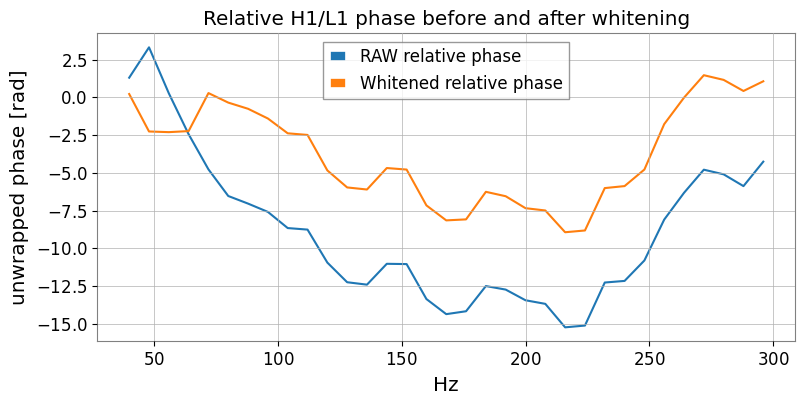

In [ ]:

def relative_phase_summary(H,L):
    nper=min(512,len(H))
    f,Pxy=signal.csd(L,H,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    _,coh=signal.coherence(H,L,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    ph=np.unwrap(np.angle(Pxy))
    m=(f>=40)&(f<=300)&np.isfinite(ph)&np.isfinite(coh)
    return f[m],ph[m],coh[m]

f_raw,ph_raw,coh_raw=relative_phase_summary(raw_H,raw_L)
f_w,ph_w,coh_w=relative_phase_summary(REF_H,REF_L)

ph_wi=np.interp(f_raw,f_w,ph_w)
phase_delta=ph_wi-ph_raw

phase_audit={
    "median_abs_phase_change_rad":float(np.median(np.abs(phase_delta))),
    "max_abs_phase_change_rad":float(np.max(np.abs(phase_delta))),
    "raw_median_coherence":float(np.median(coh_raw)),
    "white_median_coherence":float(np.median(coh_w))
}

print(json.dumps(phase_audit,indent=2))

plt.figure(figsize=(9,4))
plt.plot(f_raw,ph_raw,label="RAW relative phase")
plt.plot(f_w,ph_w,label="Whitened relative phase")
plt.xlabel("Hz")
plt.ylabel("unwrapped phase [rad]")
plt.title("Relative H1/L1 phase before and after whitening")
plt.grid(True)
plt.legend()
plt.show()


## 13 — Synthèse des sensibilités

In [ ]:

def span_ok(df,col="nonstable_fraction_resolved",status_col=None):
    d=df.copy()
    if status_col is not None and status_col in d.columns:
        d=d[d[status_col]=="OK"]
    z=d[col].dropna().to_numpy(float)
    return float(np.max(z)-np.min(z)) if len(z) else np.nan

spans={
    "PSD_METHOD_RESOLUTION":span_ok(psd_df,status_col="status"),
    "PSD_WINDOW":span_ok(window_df,status_col="status"),
    "REGULARIZATION":span_ok(reg_df),
    "SEPARATE_VS_COMMON_PSD":span_ok(common_df),
    "EDGE_TAPER":span_ok(edge_df)
}

span_df=pd.DataFrame([
    {"factor":k,"nonstable_span":v}
    for k,v in spans.items()
]).sort_values("nonstable_span",ascending=False)

display(span_df)


,factor,nonstable_span
0,PSD_METHOD_RESOLUTION,0.082609
1,PSD_WINDOW,0.060870
3,SEPARATE_VS_COMMON_PSD,0.030435
2,REGULARIZATION,0.000000
4,EDGE_TAPER,0.000000


## 14 — Verdict causal automatique

In [ ]:

finite_span=span_df[np.isfinite(span_df.nonstable_span)].copy()

RAW_NS=float(RAW_METRICS["nonstable_fraction_resolved"])
REF_NS=float(REF_METRICS["nonstable_fraction_resolved"])
WHITENING_DELTA=REF_NS-RAW_NS

if len(finite_span)==0:
    FINAL_STATUS="INCONCLUSIVE"
    DOMINANT_COMPONENT=None
else:
    DOMINANT_COMPONENT=str(finite_span.iloc[0].factor)
    top=float(finite_span.iloc[0].nonstable_span)
    second=float(finite_span.iloc[1].nonstable_span) if len(finite_span)>1 else 0.0

    clearly_dominant=bool(top>=0.15 and top>=1.5*(second+1e-12))

    if clearly_dominant:
        mapping={
            "PSD_METHOD_RESOLUTION":"PSD-METHOD-RESOLUTION-DOMINATED",
            "PSD_WINDOW":"PSD-WINDOW-DOMINATED",
            "REGULARIZATION":"REGULARIZATION-DOMINATED",
            "SEPARATE_VS_COMMON_PSD":"SEPARATE-COMMON-PSD-DOMINATED",
            "EDGE_TAPER":"EDGE-TAPER-DOMINATED"
        }
        FINAL_STATUS=mapping.get(DOMINANT_COMPONENT,"INCONCLUSIVE")
    else:
        # If none of the whitening internals has a large span while the overall
        # whitening effect remains large, classify the whitening effect as robust
        # to these internal choices.
        max_span=float(finite_span.nonstable_span.max())
        if abs(WHITENING_DELTA)>=0.30 and max_span<0.15:
            FINAL_STATUS="WHITENING-EFFECT-ROBUST"
        else:
            FINAL_STATUS="WHITENING-MULTIFACTOR-INTERACTION"

artifact={
    "step":"RACC-C.4-real.2.10",
    "event":"GW150914",
    "raw_nonstable_fraction":RAW_NS,
    "reference_whitening_nonstable_fraction":REF_NS,
    "whitening_delta":WHITENING_DELTA,
    "component_spans":spans,
    "dominant_component":DOMINANT_COMPONENT,
    "phase_audit":phase_audit,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}

print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.10",
  "event": "GW150914",
  "raw_nonstable_fraction": 0.24347826086956523,
  "reference_whitening_nonstable_fraction": 0.8826086956521739,
  "whitening_delta": 0.6391304347826087,
  "component_spans": {
    "PSD_METHOD_RESOLUTION": 0.08260869565217388,
    "PSD_WINDOW": 0.060869565217391286,
    "REGULARIZATION": 0.0,
    "SEPARATE_VS_COMMON_PSD": 0.0304347826086957,
    "EDGE_TAPER": 0.0
  },
  "dominant_component": "PSD_METHOD_RESOLUTION",
  "phase_audit": {
    "median_abs_phase_change_rad": 6.250295998729973,
    "max_abs_phase_change_rad": 6.350689766313876,
    "raw_median_coherence": 0.48629178168168,
    "white_median_coherence": 0.4932464392011241
  },
  "final_status": "WHITENING-EFFECT-ROBUST",
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "core_GVH_modified": false
}


## 15 — Stop-rule finale

Verdicts possibles :

\[
\boxed{
\texttt{PSD-METHOD-RESOLUTION-DOMINATED}
}
\]

\[
\boxed{
\texttt{PSD-WINDOW-DOMINATED}
\;|\;
\texttt{REGULARIZATION-DOMINATED}
\;|\;
\texttt{SEPARATE-COMMON-PSD-DOMINATED}
}
\]

\[
\boxed{
\texttt{EDGE-TAPER-DOMINATED}
\;|\;
\texttt{WHITENING-EFFECT-ROBUST}
\;|\;
\texttt{WHITENING-MULTIFACTOR-INTERACTION}
\;|\;
\texttt{INCONCLUSIVE}
}
\]

Même si une composante du whitening est isolée, il faudra ensuite corriger/geler le preprocessing et **retester la convergence inter-estimateurs** avant toute autorisation de `real.3`.

Les invariants restent :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]
